In [1]:
import numpy as np
from pillow_lab_rotation.ctds import CTDS
from pillow_lab_rotation.simulate import CTDSSim
from pillow_lab_rotation.plotting import plot_ctds_matrices
import matplotlib.pyplot as plt

plt.style.use('../Js.mplstyle')

### MSE between fit parameters and ground-truth parameters should go down monotonically with the amount of data

In [4]:
Ne, Ni = 5, 5
N = Ne + Ni
De, Di = 2, 3
D = De + Di

simulation = CTDSSim(De, Di, Ne, Ni)
np.random.seed(42)
simulation.create_params()

trial_list = [50, 100, 200, 500, 1000, 1500, 2000, 5000, 10000, 20000, 40000]
time_points = 100
X_all, Y_all = simulation.simulate(time_points, trial_list[-1])

A_loss = []
C_loss = []
Q_loss = []
R_loss = []
A_true, C_true, Q_true, V0_true, mu0_true, R_true = simulation.get_params()
np.random.seed(0)
ctds = CTDS(De, Di, Ne, Ni)

for n_trials in trial_list:
    print(f'Fitting with {n_trials} trials')
    # Initialize at the ground truth parameters
    ctds.A = A_true.copy()
    ctds.C = C_true.copy()
    ctds.Q = Q_true.copy()
    ctds.R = R_true.copy()
    ctds.V0 = V0_true.copy()
    ctds.mu0 = mu0_true.copy()

    Y = Y_all[:n_trials]
    ctds.fit(Y)

    C_prime = ctds.C
    H = np.linalg.inv(C_prime.T @ C_prime) @ C_prime.T @ C_true
    H_inv = np.linalg.inv(H)

    A_rec = H_inv @ ctds.A @ H
    C_rec = ctds.C @ H
    Q_rec = H_inv @ ctds.Q @ H_inv.T

    A_loss.append(np.mean((A_rec - A_true)**2))
    C_loss.append(np.mean((C_rec - C_true)**2))
    Q_loss.append(np.mean((Q_rec - Q_true)**2))
    R_loss.append(np.mean((ctds.R - R_true)**2))

Fitting with 50 trials
Fitting with 100 trials
Fitting with 200 trials
Fitting with 500 trials
Fitting with 1000 trials
Fitting with 1500 trials
Fitting with 2000 trials
Fitting with 5000 trials
Fitting with 10000 trials
Fitting with 20000 trials
Fitting with 40000 trials


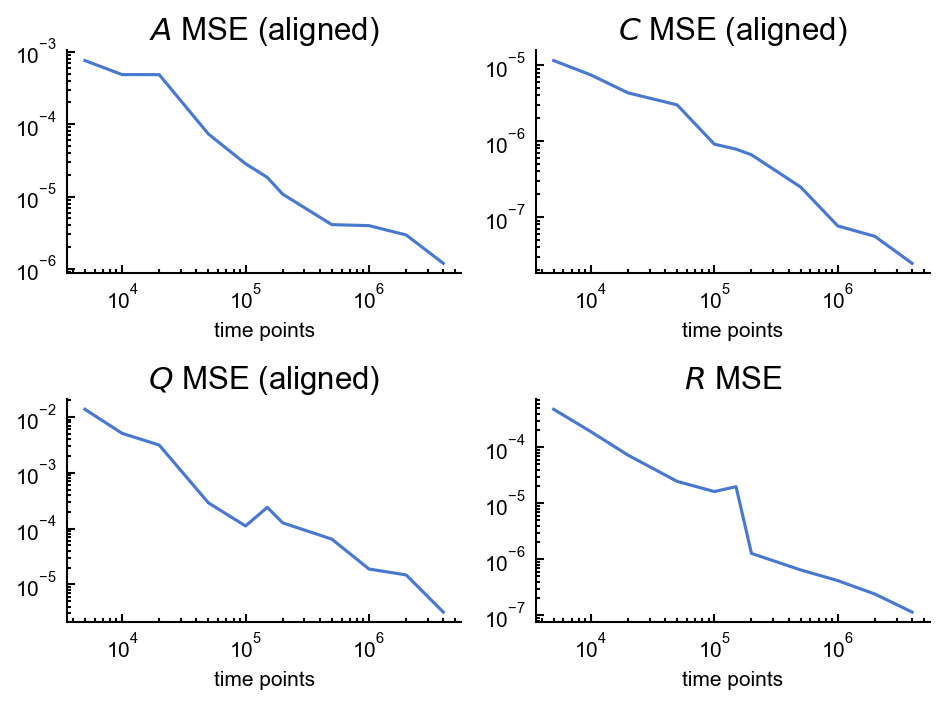

In [3]:
fig, axes = plt.subplots(2, 2)
titles = ['$A$ MSE (aligned)', '$C$ MSE (aligned)', '$Q$ MSE (aligned)', '$R$ MSE']
losses = [A_loss, C_loss, Q_loss, R_loss]

for ax, title, loss in zip(axes.flat, titles, losses):
    ax.plot(time_points * np.array(trial_list), loss)
    ax.set_title(title)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('time points')

fig.tight_layout()